In [41]:
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import binom

### Ticker Choice is Goldman Sachs for volatility clustering
#### Data Cleaning and visualisation comes first before model implementation - first step is conversion to dollar bars (to make IID per MLdP - AFML)

In [42]:
ticker = yf.download("GS", start="2024-01-01", end="2024-12-31")
print(ticker.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open   Volume
Ticker              GS          GS          GS          GS       GS
Date                                                               
2024-01-02  367.967194  368.763234  362.177149  362.944732  2263100
2024-01-03  361.798096  365.219049  357.031486  363.778652  2265300
2024-01-04  362.897339  366.820538  361.949703  363.465898  1618300
2024-01-05  366.204590  369.075927  361.125244  361.921284  2913900
2024-01-08  368.497833  368.706314  362.025490  365.759179  1902600


In [43]:
datecheck = ticker.copy()
precount = datecheck['Open'].count()
datecheck.dropna(inplace=False)
postcount = datecheck['Open'].count()
ratio = postcount / precount
print(ratio)

Ticker
GS    1.0
dtype: float64


No null dates - does not have skewed data around weekly or monthly view in that case. All the same, use mask to convert to dollar bars and then proceed.

Without access to tick / trade level data the dollar bar is less useful - but for the sake of the method it will be used anyway.

AttributeError: This method only works with the ScalarFormatter

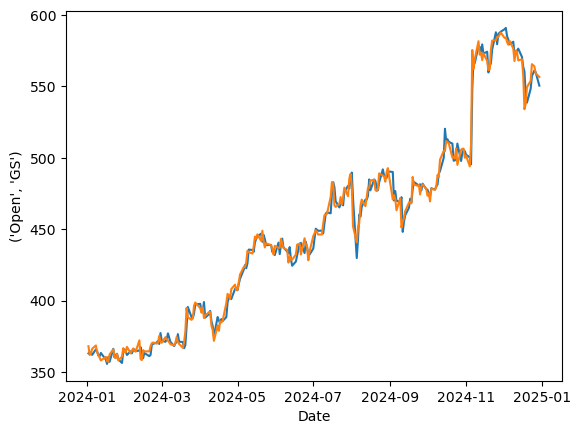

In [44]:
ax = sns.lineplot(x=ticker.index, y=ticker[('Open', 'GS')])
sns.lineplot(x=ticker.index, y=ticker[('Close', 'GS')], ax=ax)
ax.ticklabel_format(style='plain', axis='both')

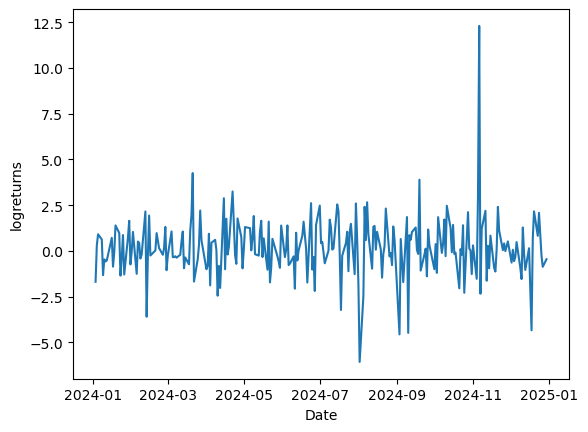

In [45]:
ticker['logreturns'] = 100 * np.log(ticker['Close'] / ticker['Close'].shift(1))
ax = sns.lineplot(x=ticker.index, y=ticker['logreturns'])
ax.ticklabel_format(axis='y')

In [46]:
from arch import arch_model
model = arch_model(ticker['logreturns'].dropna(), vol='Garch', p=1, q=1, dist='t')
res = model.fit(disp='off')
sig = res.conditional_volatility /100

In [47]:
print(res.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   logreturns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -440.491
Distribution:      Standardized Student's t   AIC:                           890.981
Method:                  Maximum Likelihood   BIC:                           908.589
                                              No. Observations:                  250
Date:                      Mon, Jun 29 2026   Df Residuals:                      249
Time:                              11:21:48   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

In [48]:
nu = res.params['nu']
alpha_var = 0.01

t_q = stats.t.ppf(alpha_var, df=nu)
Var99 = sig *t_q
CVar99 = sig * (nu + t_q**2) / (nu -1) * stats.t.pdf(t_q, df = nu) / alpha_var

In [49]:
ticker['Var99'] = Var99
ticker['CVar99'] = CVar99
ticker['Var99'] = ticker['Var99'].fillna(0)
ticker['CVar99'] = ticker['CVar99'].fillna(0)
ticker['breach'] = (ticker['logreturns'] / 100 < ticker['Var99']).astype(int)
ticker['CVar99'] = ticker['CVar99'].fillna(0)
ticker['breach'] = (ticker['logreturns'] / 100 < ticker['Var99']).astype(int)

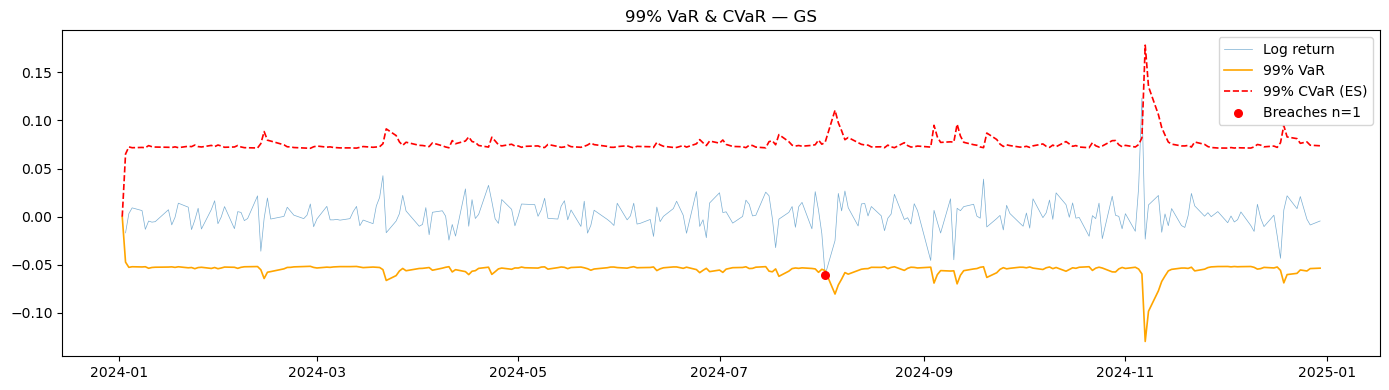

In [51]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ticker.index, ticker['logreturns'] / 100, lw=0.5, alpha=0.6, label='Log return')
ax.plot(ticker.index, ticker['Var99'],  color='orange', lw=1.2, label='99% VaR')
ax.plot(ticker.index, ticker['CVar99'], color='red',    lw=1.2, ls='--', label='99% CVaR (ES)')
b = ticker[ticker['breach'] == 1]
ax.scatter(b.index, b['logreturns'] / 100, color='red', s=30, zorder=5,
           label=f'Breaches n={len(b)}')
ax.legend(); ax.set_title('99% VaR & CVaR — GS')
plt.tight_layout(); plt.show()

In [52]:
breach_rate = ticker['breach'].mean()
n, x        = len(ticker), ticker['breach'].sum()
p_kupiec    = binom.sf(x - 1, n, alpha_var)
print(f"Breach rate : {breach_rate:.4f}  (expected {alpha_var})")
print(f"Kupiec p    : {p_kupiec:.4f}  ({'PASS' if p_kupiec > 0.05 else 'FAIL'})")

Breach rate : 0.0040  (expected 0.01)
Kupiec p    : 0.9198  (PASS)


In [54]:
low_q  = sig.quantile(0.33)
high_q = sig.quantile(0.67)
 
ticker['regime'] = 'Medium'
ticker.loc[sig.index[sig <= low_q], 'regime'] = 'Low'
ticker.loc[sig.index[sig >= high_q], 'regime'] = 'High'
ticker.loc[sig.values >= high_q, 'regime'] = 'High'
 
colours = {'Low': '#3FB950', 'Medium': '#D4A017', 'High': '#F85149'}
 
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
 
for reg, grp in ticker.groupby('regime'):
    axes[0].scatter(grp.index, grp['Close'], c=colours[reg], s=3, label=reg)
axes[0].set_title('GS Price — Volatility Regimes')
axes[0].legend(title='Regime')
 
axes[1].plot(ticker.index, sig * 100, color='gold', lw=0.8)
for reg, grp in ticker.groupby('regime'):
    axes[1].fill_between(grp.index, 0, sig.loc[grp.index] * 100,
                         color=colours[reg], alpha=0.25)
axes[1].set_title('Conditional Volatility (%) — Regime Bands')
 
plt.tight_layout(); plt.show()
 
print(ticker.groupby('regime')['logreturns'].agg(['mean', 'std', 'count']).round(4))

IndexError: Boolean index has wrong length: 250 instead of 251

In [ ]:
gjr = arch_model(ticker['logreturns'].dropna(), vol='Garch', p=1, o=1, q=1, dist='t').fit(disp='off')
print(gjr.summary())
 
alpha_g = gjr.params['alpha[1]']
gamma_g = gjr.params['gamma[1]']
omega_g = gjr.params['omega']
 
print(f"\nγ = {gamma_g:.4f}  p = {gjr.pvalues['gamma[1]']:.4f}")
 
# ── news impact curve ─────────────────────────────────────
shocks  = np.linspace(-0.05, 0.05, 200)
nic_pos = omega_g + alpha_g * shocks**2 * 1e4
nic_neg = omega_g + (alpha_g + gamma_g) * shocks**2 * 1e4
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(shocks * 100, nic_pos, color='steelblue', label='Positive shock')
ax.plot(shocks * 100, nic_neg, color='red', ls='--', label='Negative shock')
ax.axvline(0, color='grey', lw=0.6)
ax.set_xlabel('Shock (%)'); ax.set_ylabel('Variance response')
ax.set_title('GJR-GARCH News Impact Curve')
ax.legend(); plt.tight_layout(); plt.show()

NameError: name 'r' is not defined